In [6]:
import typing as tp

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.func import functional_call, hessian
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim

import numpy as np

import copy

In [7]:
def make_hessian(
    model: nn.Module, x: tuple, y: torch.Tensor, loss_fn: tp.Callable
) -> tp.Any:
    """Computes the Hessian of `model` evaluated at `x`.

    Args:
        model (nn.Module): A neural network
        x (tuple): inputs to the network s.t. model(*x) is a valid statement
        y (torch.Tensor): Targets
        loss_fn (callable): Loss function of form f(outputs, target)

    Returns:
        tp.Any: Hessian
    """

    # Zero existing gradients
    for p in model.parameters():
        p.grad = None

    make_loss = lambda params, x, y: loss_fn(functional_call(model, params, x), y)

    params = dict(model.named_parameters())
    # This returns a nested dictionary of dictionaries
    hess_dict: dict[str, dict[str, torch.Tensor]] = hessian(make_loss)(params, x, y)

    # Effective shape: (num_params, num_params)
    # example: A linear model mapping R^4 -> R with bias has 2 parameters: weight and bias.
    # within these there are 5 elements (4 in weight, 1 in bias). So `hess_dict` is a dict of
    # dicts, with the keys mapping to different blocks of the hessian matrix: dict[i][j] gives
    # grad_i ( grad_j (loss) )  [order might be off here, but i think it should be symmetric anyway]
    # The shapes of these (after flattening) are H_ww: (4, 4), H_wb: (4, 1), H_bw: (1, 4), H_bb: (1, 1) in this example
    # These form the four blocks of the full Hessian matrix of shape (5, 5).
    #
    #   --------------------
    #   |           |      |
    #   |   H_ww    | H_wb |
    #   |           |      |
    #   |           |      |
    #   |------------------|
    #   | H_bw      | H_bb |
    #   --------------------

    named_params = {k: v for k, v in model.named_parameters()}
    # Important that order of parameters is consistent
    param_names = sorted(list(named_params.keys()))
    param_count = sum(p.numel() for p in named_params.values())
    # hess_mat = torch.empty((param_count, param_count))
    with torch.no_grad():
        hess_mat = torch.full(
            (param_count, param_count),
            float("nan"),
            device=next(model.parameters()).device,  # assume all on same device
        )
        cur_row = 0
        for i_key in param_names:
            cur_col = 0
            block_height = 0
            for j_key in param_names:
                # shape: (*param_i.shape, *param_j.shape)
                hess_block_ij = hess_dict[i_key][j_key]

                # reshape to 2D matrix
                hess_block_ij = hess_block_ij.reshape(
                    named_params[i_key].numel(), named_params[j_key].numel()
                )
                block_height = hess_block_ij.shape[0]
                hess_mat[
                    cur_row : cur_row + hess_block_ij.shape[0],
                    cur_col : cur_col + hess_block_ij.shape[1],
                ] = hess_block_ij
                cur_col += hess_block_ij.shape[1]
            cur_row += block_height

    return hess_mat


def make_gradient(
    model: nn.Module, x: tuple, y: torch.Tensor, loss_fn: tp.Callable
) -> torch.Tensor:
    """Computes the gradient of `model` evaluated at `x`. I'm sure there should be a
    way to rewrite the Hessian computation to produce this as a byproduct, but
    I don't feel like figuring it out right now.

    Args:
        model (nn.Module): A neural network
        x (tuple): inputs to the network s.t. model(*x) is a valid statement
        y (torch.Tensor): Targets
        loss_fn (callable): Loss function of form f(outputs, target)

    Returns:
        torch.Tensor: Gradient
    """
    # Zero existing gradients
    for p in model.parameters():
        p.grad = None

    outputs = model(*x)
    loss = loss_fn(outputs, y)
    loss.backward()

    named_params = list(model.named_parameters())
    named_params.sort(key=lambda tup: tup[0])  # sort by name for consistency
    return torch.cat([p.grad.flatten() for _, p in named_params])


def make_newton_step(
    model: nn.Module,
    x: tuple,
    y: torch.Tensor,
    loss_fn: tp.Callable,
    update_params: bool = True,
    clip_step_size: float | None = 1.0,
) -> dict[str, torch.Tensor]:
    """Runs one step of Newton's algorithm on a model with parameters `params`.
    The parameters will be optionally modified in-place and the computed
    optimization step is returned for each parameter.

    Args:
        model (nn.Module): The neural network model
        x (tuple): Inputs to the network
        y (torch.Tensor): Targets
        loss_fn (callable): Loss function of form f(outputs, target)
        update_params (bool, optional): Whether to update the parameters in-place. Defaults to True.

    Returns:
        list[torch.Tensor]: Optimal step for each parameter.
    """
    hessian = make_hessian(model, x, y, loss_fn)
    gradient = make_gradient(model, x, y, loss_fn)
    # Ultimately, we want the inverse hessian-gradient product:  -H^{-1} g
    with torch.no_grad():
        hgp = -torch.linalg.lstsq(hessian, gradient).solution
    if clip_step_size is not None:
        step_norm = torch.norm(hgp)
        if step_norm > clip_step_size:
            hgp = hgp * clip_step_size / step_norm

    # Split the flat hgp into parameter-shaped chunks
    named_params = list(model.named_parameters())
    named_params.sort(key=lambda tup: tup[0])  # sort by name for consistency
    numels = [p.numel() for _, p in named_params]
    updates = torch.split(hgp, numels)

    param_steps = {
        name: step.reshape(param.shape)
        for (name, param), step in zip(named_params, updates)
    }

    if update_params:
        # Update parameters in-place
        with torch.no_grad():
            for name, param in model.named_parameters():
                param += param_steps[name]

    return param_steps

def compute_newton_update(
    model: nn.Module,
    x: tuple,
    y: torch.Tensor,
    loss_fn: tp.Callable,
    update_params: bool = True,
    clip_step_size: float | None = 1.0,
) -> torch.Tensor:
    """Runs the update provided by one step of Newton's algorithm on a model with parameters `params`.
    The parameters will be optionally modified in-place and the computed
    optimization step is returned for each parameter.

    Args:
        model (nn.Module): The neural network model
        x (tuple): Inputs to the network
        y (torch.Tensor): Targets
        loss_fn (callable): Loss function of form f(outputs, target)
        update_params (bool, optional): Whether to update the parameters in-place. Defaults to True.

    Returns:
        list[torch.Tensor]: Optimal step for each parameter.
    """
    hessian = make_hessian(model, x, y, loss_fn)
    gradient = make_gradient(model, x, y, loss_fn)
    # Ultimately, we want the inverse hessian-gradient product:  -H^{-1} g
    with torch.no_grad():
        hgp = -torch.linalg.lstsq(hessian, gradient).solution
    return hgp.clone()

In [8]:
class Square(nn.Module):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x**2


class SyntheticDataset(Dataset):
    def __init__(self, dset_size: int, d_data: int) -> None:
        super().__init__()
        self.data = torch.randn(dset_size, d_data)
        self.true_w = torch.linspace(1, 2, d_data)
        self.targets = ((self.data) * self.true_w[None, :]).sum(
            dim=1, keepdim=True
        )**2 + 0.5 * torch.randn(dset_size, 1)
        self.targets -= torch.mean(self.targets)
        self.targets /= torch.std(self.targets)

    def __len__(self) -> int:
        return self.data.shape[0]

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.data[idx, :], self.targets[idx, :]

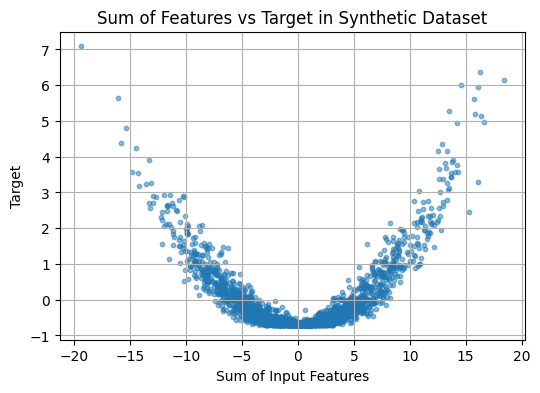

In [15]:
d_data = 32
num_epochs = 500
dataset_size = 2000
batch_size = 200
hidden_dim = 64

#model = nn.Linear(d_data, 1)
model = nn.Sequential(nn.Linear(d_data, hidden_dim, bias=False), nn.ReLU(), nn.Linear(hidden_dim, 1, bias=False))

loss = nn.MSELoss()

dataset = SyntheticDataset(dataset_size, d_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

data_np = dataset.data.numpy()
targets_np = dataset.targets.numpy()

# Plot sum of features vs target, just as an example
plt.figure(figsize=(6, 4))
plt.scatter(data_np.sum(axis=1), targets_np, alpha=0.5, s=10)
plt.xlabel("Sum of Input Features")
plt.ylabel("Target")
plt.title("Sum of Features vs Target in Synthetic Dataset")
plt.grid(True)
plt.show()

In [20]:
losses = []
cos_sims = []
verbose = False
num_epochs = 50
lr = 1e-2
clip = False

print(f"Initial loss:")

# Initialize model weights with better initialization
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

model.apply(init_weights)

# opt = optim.SGD(model.parameters(), lr=1e-3)
opt = optim.Adam(model.parameters(), lr=1e-3)
# opt = optim.Muon(model.parameters(), lr=lr)

for data, targets in dataloader:
    outputs = model(data)
    train_loss = loss(outputs, targets)
    print(f"Train loss {train_loss.item():.4f}")
    losses.append(train_loss.item())
    break

for step in range(num_epochs):
    for data, targets in dataloader:
        #compute newton update on a copy of everything to not mess with the model graph
        model_copy = copy.deepcopy(model)
        newton_update = compute_newton_update(model_copy, (data,), targets, loss)
        del model_copy
        #get model parameters as a vector
        with torch.no_grad():
            named_params_copy_old = list(model.named_parameters())
            named_params_copy_old.sort(key=lambda tup: tup[0])  # sort by name for consistency
            params_copy_old = torch.cat([p.data.flatten() for _, p in named_params_copy_old]).clone()
        #apply loss backward / optimizer step / zero grads
        outputs = model(data)  # Recompute outputs for current batch
        train_loss = loss(outputs, targets)
        train_loss.backward()
        # Add gradient clipping to prevent exploding gradients
        if clip: torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        opt.step()
        opt.zero_grad()
        with torch.no_grad():
            named_params_copy_new = list(model.named_parameters())
            named_params_copy_new.sort(key=lambda tup: tup[0])  # sort by name for consistency
            params_copy_new = torch.cat([p.data.flatten() for _, p in named_params_copy_new]).clone()

            #check param change
            param_change = params_copy_new - params_copy_old
            if verbose: print(f"Param change norm {torch.norm(param_change).item():.4f}")
            if verbose: print(f"hgp norm {torch.norm(newton_update).item():.4f}")

            #check cos similarity between newton update and param change
            cos_sim = torch.nn.functional.cosine_similarity(newton_update, param_change, dim=0)
            cos_sims.append(cos_sim.item())
            if verbose: print(f"Cosine similarity {cos_sim.item():.4f}")
        
    # Compute average loss over full dataset for more accurate reporting
    with torch.no_grad():
        epoch_losses = []
        for data, targets in dataloader:
            outputs = model(data)
            train_loss = loss(outputs, targets)
            epoch_losses.append(train_loss.item())
        avg_loss = sum(epoch_losses) / len(epoch_losses)
        losses.append(avg_loss)
        print(f"Epoch {step}: Train loss {avg_loss:.4f}")

Initial loss:
Train loss 1.6930
Epoch 0: Train loss 1.3001
Epoch 1: Train loss 1.1579
Epoch 2: Train loss 1.0677
Epoch 3: Train loss 1.0052
Epoch 4: Train loss 0.9596
Epoch 5: Train loss 0.9202
Epoch 6: Train loss 0.8838
Epoch 7: Train loss 0.8482
Epoch 8: Train loss 0.8112
Epoch 9: Train loss 0.7740
Epoch 10: Train loss 0.7338
Epoch 11: Train loss 0.6928
Epoch 12: Train loss 0.6481
Epoch 13: Train loss 0.6023
Epoch 14: Train loss 0.5545
Epoch 15: Train loss 0.5064
Epoch 16: Train loss 0.4587
Epoch 17: Train loss 0.4103
Epoch 18: Train loss 0.3642
Epoch 19: Train loss 0.3212
Epoch 20: Train loss 0.2821
Epoch 21: Train loss 0.2477
Epoch 22: Train loss 0.2172
Epoch 23: Train loss 0.1922
Epoch 24: Train loss 0.1712
Epoch 25: Train loss 0.1543
Epoch 26: Train loss 0.1410
Epoch 27: Train loss 0.1302
Epoch 28: Train loss 0.1218
Epoch 29: Train loss 0.1151
Epoch 30: Train loss 0.1096
Epoch 31: Train loss 0.1053
Epoch 32: Train loss 0.1015
Epoch 33: Train loss 0.0983
Epoch 34: Train loss 0.095

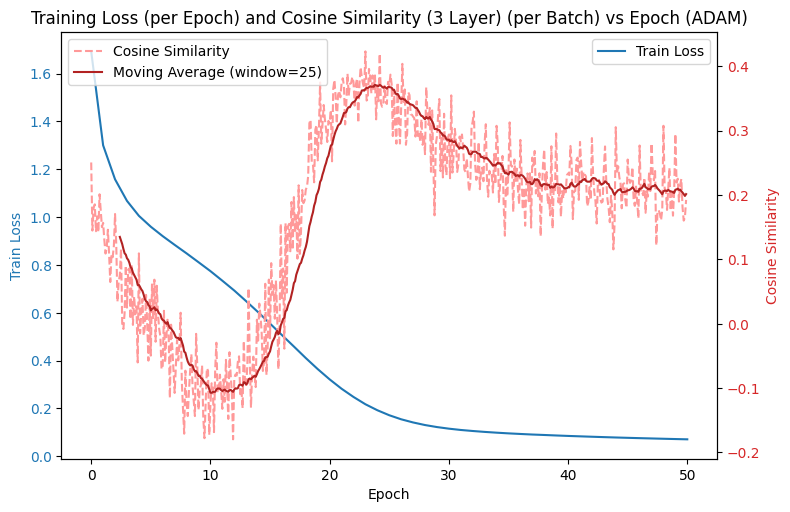

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color=color)
ax1.plot(range(len(losses)), losses, color=color, label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper right')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

# Calculate total number of steps (batches) and batches per epoch for x-scaling
num_train_batches = len(cos_sims) // (len(losses) - 1) if len(losses) > 1 else len(cos_sims)
batch_steps = np.arange(len(cos_sims)) / num_train_batches  # fractional epoch for each batch

# Plot cosine similarity in light red
light_red = '#ff9999'
ax2.set_ylabel('Cosine Similarity', color='tab:red')
ax2.plot(batch_steps, cos_sims, color=light_red, linestyle='--', label='Cosine Similarity')

# Compute and plot moving average in dark red
window_size = 25 if len(cos_sims) > 50 else max(3, len(cos_sims)//10)
cos_sims_ma = np.convolve(cos_sims, np.ones(window_size)/window_size, mode='valid')
batch_steps_ma = batch_steps[window_size-1:]
dark_red = '#b22222'
ax2.plot(batch_steps_ma, cos_sims_ma, color=dark_red, label=f'Moving Average (window={window_size})')

ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper left')

fig.tight_layout()
plt.title('Training Loss (per Epoch) and Cosine Similarity (3 Layer) (per Batch) vs Epoch (ADAM)')
plt.show()
